In [24]:
import math
import pygrib
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime
import sys
#                                                                                          
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.interpolate import cross_section
from metpy.units import units

In [25]:
# GSMの読み込む初期値の年月日時をUTCで与えます。
i_year =2021
i_month = 8
i_day = 13
i_hourZ = 18
#
# 予想時間を与える。この値は注意が必要です。下3桁目が日数、下２桁で時間で与えます。
#  初期値なら0、18時間後なら18、24時間後なら100、36時間後なら112となります。
i_ft = 0
#
#  時間に変換
ft_hours=int(i_ft/100) * 24 + int(i_ft%100)
#
# 上端の気圧面を指定
tagHp=100
#
# 湿度のデータがある上端の気圧を指定(GSMのGRIB2は300hPaまである)
topRh=300
#
# 断面の位置を指定
f_lat_start = 45.0
f_lat_end = 25.0
f_lon_start = 130.0
f_lon_end = 130.0
#
# 断面図左上に表示する、500hPa面天気図の表示範囲指定
map_latlon = (121.0, 151.0, 22.0, 48.0)
#
# 断面図に表示する矢羽  0:断面に並行・垂直の風を描画  1:北風が下に向くよう風を描画
flag_wind=1
#
# データの格納先フォルダー名
##!!! GRIB2データの保存先をFolderを指定すること !!!
data_fld="/Users/hogehoge/Data/gsm/"
#
####################################################
#
## データ読み込み部
# 読み込むGRIB2形式GSMのファイル名
gsm_fn_t="Z__C_RJTD_{0:4d}{1:02d}{2:02d}{3:02d}0000_GSM_GPV_Rgl_FD{4:04d}_grib2.bin"
gr_fn= gsm_fn_t.format(i_year,i_month,i_day,i_hourZ,i_ft)
#
# データOpen
grbs = pygrib.open(data_fld + gr_fn)
#
# データ読み込み。 tagHpの等圧面から下部のデータを全て読み込みます。
grbHt = grbs(shortName="gh",typeOfLevel='isobaricInhPa',level=lambda l:l >= tagHp)
grbWu = grbs(shortName="u",typeOfLevel='isobaricInhPa',level=lambda l:l >= tagHp)
grbWv = grbs(shortName="v",typeOfLevel='isobaricInhPa',level=lambda l:l >= tagHp)
grbTm = grbs(shortName="t",typeOfLevel='isobaricInhPa',level=lambda l:l >= tagHp)
grbRh = grbs(shortName="r",typeOfLevel='isobaricInhPa',level=lambda l:l >= topRh)
#
# 読み込んだデータの時刻取得
dt = grbHt[0].validDate
print(dt)

2021-08-13 18:00:00


In [26]:
## データの3次元化
#
# GPVの緯度・経度の値を配列に
lats2, lons2 = grbHt[0].latlons()
lats = lats2[:,0]
lons = lons2[0,:]
#
# GPVの気圧面の値を配列化
levels = np.array([g['level'] for g in grbHt])
levels_Rh = np.array([g['level'] for g in grbRh])
indexes = np.argsort(levels)[::-1]
indexes_Rh = np.argsort(levels_Rh)[::-1]
x, y = grbHt[0].values.shape
#print(levels,levels_Rh)
#print(indexes,indexes_Rh)
#print(x,y)
#
# 全てのデータを0に初期化して、読み込んだGPVを代入する
cubeHt = np.zeros([len(levels), x, y])
cubeWu = np.zeros([len(levels), x, y])
cubeWv = np.zeros([len(levels), x, y])
cubeTm = np.zeros([len(levels), x, y])
cubeRh = np.zeros([len(levels), x, y])
for i in range(len(levels)):
    cubeHt[i,:,:] = grbHt[indexes[i]].values
    cubeWu[i,:,:] = grbWu[indexes[i]].values
    cubeWv[i,:,:] = grbWv[indexes[i]].values
    cubeTm[i,:,:] = grbTm[indexes[i]].values
#
# 300hPaより高い高度では、便宜上、湿度0%とする
for i in range(len(levels_Rh)):
    cubeRh[i,:,:] = grbRh[indexes_Rh[i]].values
#
#print(cubeHt[0,:,:].max(),cubeHt[10,:,:].max())
#print(cubeRh[0,:,:].max(),cubeRh[10,:,:].max())

In [27]:
## 露点温度や収束などを計算するために、データセットを作る
ds = xr.Dataset(
    {
        "Geopotential_height": (["level","lat", "lon"], cubeHt * units.meter),
        "temperature": (["level","lat", "lon"], cubeTm * units('K')),
        "relative_humidity": (["level","lat", "lon"], cubeRh * units('%')),
        "u_wind": (["level","lat", "lon"], cubeWu * units('m/s')),
        "v_wind": (["level","lat", "lon"], cubeWv * units('m/s')),
    },
    coords={
        "level": levels,
        "lat": lats,
        "lon": lons,
        "time": [grbHt[0].validDate],
    },
)
ds['Geopotential_height'].attrs['units'] = 'm'
ds['temperature'].attrs['units']='K'
ds['relative_humidity'].attrs['units']='%'
ds['u_wind'].attrs['units']='m/s'
ds['v_wind'].attrs['units']='m/s'
ds['level'].attrs['units'] = 'hPa'
ds['lat'].attrs['units'] = 'degrees_north'
ds['lon'].attrs['units'] = 'degrees_east'
#
## 必要な物理量を計算する
# 露点温度算出
ds['dewpoint_temperature'] = mpcalc.dewpoint_from_relative_humidity(
        ds['temperature'],ds['relative_humidity'])
ds['dewpoint_temperature'].attrs['units']='K'
#
# 収束・発散算出
ds['divergence'] = mpcalc.divergence(ds['u_wind'],ds['v_wind'])
ds['dewpoint_temperature'].attrs['units']='1/s'
#
## Parse full dataset
dsp= ds.metpy.parse_cf()
#
print(dsp)

/Users/rkurora/opt/anaconda3/envs/met_env/lib/python3.8/site-packages/pint/numpy_func.py:303: RuntimeWarning: divide by zero encountered in log
  result_magnitude = func(*stripped_args, **stripped_kwargs)
/Users/rkurora/opt/anaconda3/envs/met_env/lib/python3.8/site-packages/pint/quantity.py:1237: RuntimeWarning: invalid value encountered in true_divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coo

<xarray.Dataset>
Dimensions:               (lat: 361, level: 12, lon: 720)
Coordinates:
  * level                 (level) int64 1000 925 850 700 600 ... 250 200 150 100
  * lat                   (lat) float64 90.0 89.5 89.0 ... -89.0 -89.5 -90.0
  * lon                   (lon) float64 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    metpy_crs             object Projection: latitude_longitude
Data variables:
    Geopotential_height   (level, lat, lon) float64 <Quantity([[[  107.978088...
    temperature           (level, lat, lon) float64 <Quantity([[[272.52702332...
    relative_humidity     (level, lat, lon) float64 <Quantity([[[98.77835011 ...
    u_wind                (level, lat, lon) float64 <Quantity([[[ 7.27482033 ...
    v_wind                (level, lat, lon) float64 <Quantity([[[-0.49662209 ...
    dewpoint_temperature  (level, lat, lon) float64 <Quantity([[[ -0.79137947...
    divergence            (level, lat, lon) float64 <Quantity([[[            ...


In [28]:
## 断面図データセットの作成   
start = (f_lat_start, f_lon_start)
end   = (f_lat_end, f_lon_end)
#
ax_cross='lon'
if (f_lat_start - f_lat_end)**2 > (f_lon_start - f_lon_end)**2:
  ax_cross='lat'
cross = cross_section(dsp, start, end)
#
#print(cross)
#
## 描画するデータを算出し、データセットに加える
# 温位、相当温位、相対湿度、風を断面に平行・垂直成分を描画する
cross['Potential_temperature'] = mpcalc.potential_temperature(
    cross['level'] * units.hPa,
    cross['temperature'])
cross['Equivalent_Potential_temperature'] = mpcalc.equivalent_potential_temperature(
    cross['level'], cross['temperature'], cross['dewpoint_temperature'])
cross['u_wind'] = (cross['u_wind']).metpy.convert_units('knots')
cross['v_wind'] = (cross['v_wind']).metpy.convert_units('knots')
cross['t_wind'], cross['n_wind'] = mpcalc.cross_section_components(
    cross['u_wind'],cross['v_wind'])
#
#print(cross)

<ipython-input-32-e8508663c3d9>:54: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(np.arange(1000, 200, -100))


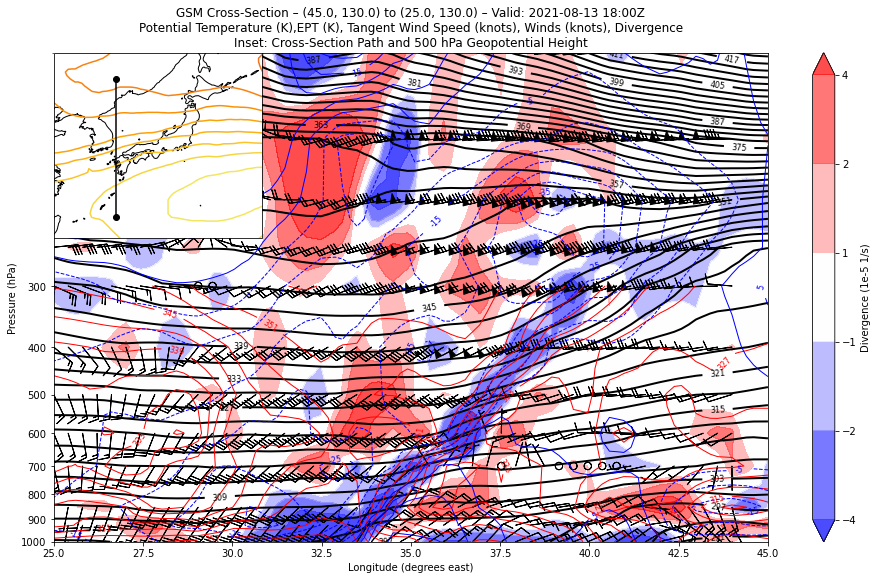

In [32]:
## 断面図描画
#
# 断面図左上に描画する500hPa面天気図の描画位置
map_x_y_width_height = [0.1255, 0.572, 0.18, 0.33]
#
# 図の大きさを指定                                                                         
fig = plt.figure(1, figsize=(16., 9.))
ax = plt.axes()
#
# シェード:収束・発散
clevs_div = [-4,-2,-1,1,2,4]
div_contour = ax.contourf(cross[ax_cross], cross['level'], cross['divergence']*1e5,
                         clevs_div, cmap=plt.cm.bwr, extend='both', alpha = 0.7)
div_colorbar = fig.colorbar(div_contour)               
#                                                                                          
# 温位(黒実線)とラベル 
theta_contour = ax.contour(cross[ax_cross], cross['level'],
                           cross['Potential_temperature'],
                           levels=np.arange(252, 450, 3), colors='k', linewidths=2)
theta_contour.clabel(theta_contour.levels[1::2], fontsize=8, colors='k', inline=1,
                     inline_spacing=8, fmt='%i', rightside_up=True, use_clabeltext=True)
#
# 相当温位(赤実線)とラベル                                 
etheta_contour = ax.contour(cross[ax_cross], cross['level'],
                            cross['Equivalent_Potential_temperature'],
                            levels=np.arange(252, 450, 3), colors='r', linewidths=1)
etheta_contour.clabel(etheta_contour.levels[1::2], fontsize=8, colors='r', inline=1,
                     inline_spacing=8, fmt='%i', rightside_up=True, use_clabeltext=True)
#
# 断面の平行成分の風速表示(青実線：マイナスは点線表示となる)
v_contour = ax.contour(cross[ax_cross], cross['level'],
                       cross['t_wind'],
                       levels=np.arange(-100, 100, 5), colors='b', linewidths=1)
v_contour.clabel(v_contour.levels[1::2], fontsize=8, colors='b', inline=1,
                inline_spacing=8, fmt='%i', rightside_up=True, use_clabeltext=True)
#                                                                                          
# 風の表示                                                                                 
#  矢羽を間引き指定                                                                        
wind_slc_vert = list(range(0, len(levels),1))
wind_slc_horz = slice(5, 100, 2)
if flag_wind == 0:
  ## Tangential / Normal Winds                                                             
  ax.barbs(cross[ax_cross][wind_slc_horz], cross['level'][wind_slc_vert],
         cross['t_wind'][wind_slc_vert, wind_slc_horz],
         cross['n_wind'][wind_slc_vert, wind_slc_horz], color='k')
else:
  ## U / V Winds                                                                           
  ax.barbs(cross[ax_cross][wind_slc_horz], cross['level'][wind_slc_vert],
         cross['u_wind'][wind_slc_vert, wind_slc_horz],
         cross['v_wind'][wind_slc_vert, wind_slc_horz], color='k')
#
# Y軸をlog指定、ラベル指定、目盛り指定                                                     
ax.set_yscale('symlog')                                                             
ax.set_yticklabels(np.arange(1000, 200, -100))
ax.set_ylim(cross['level'].max(), 100.0)
ax.set_yticks(np.arange(1000, 290, -100))
#                                                                                          
## 左上の500hPa高度の天気図表示用
#  定義:CRS and inset axes                                                             
data_crs = dsp['Geopotential_height'].metpy.cartopy_crs
# 地図の表示位置指定                                                                                                                                        
ax_inset = fig.add_axes(map_x_y_width_height, projection=data_crs)
# 地図の表示範囲指定                                                                                                                 
ax_inset.set_extent(map_latlon)
# 500hPa高度Plot(高度線の指定)                                                             
ax_inset.contour(ds['lon'], ds['lat'], ds['Geopotential_height'].sel(level=500.),
                 levels=np.arange(5100, 6000, 30), cmap='inferno')
# 断面の位置をPlot                                                                         
endpoints = data_crs.transform_points(ccrs.Geodetic(),
                 *np.vstack([start, end]).transpose()[::-1])
ax_inset.scatter(endpoints[:, 0], endpoints[:, 1], c='k', zorder=2)
ax_inset.plot(cross['lon'], cross['lat'], c='k', zorder=2)
#
# 海岸線を描画                                                 
ax_inset.coastlines()
#
## タイトルや軸ラベル                                                                     
ax_inset.set_title('')
if flag_wind == 0:
  ax.set_title('GSM Cross-Section \u2013 {} to {} \u2013 Valid: {}\n'
             'Potential Temperature (K),EPT (K), Tangent Wind Speed (knots), '
             'Tangential/Normal Winds (knots), Divergence\n'
             'Inset: Cross-Section Path and 500 hPa Geopotential Height'.format(
                 start, end, dt.strftime('%Y-%m-%d %H:%MZ')))
else:
  ax.set_title('GSM Cross-Section \u2013 {} to {} \u2013 Valid: {}\n'
             'Potential Temperature (K),EPT (K), Tangent Wind Speed (knots), '
             'Winds (knots), Divergence\n'
             'Inset: Cross-Section Path and 500 hPa Geopotential Height'.format(
                 start, end, dt.strftime('%Y-%m-%d %H:%MZ')))
ax.set_ylabel('Pressure (hPa)')
ax.set_xlabel('Longitude (degrees east)')
div_colorbar.set_label('Divergence (1e-5 1/s)')
#
plt.show() 